<a href="https://colab.research.google.com/github/msussman42/CQE/blob/main/LaxWendroffJohnBurkhardt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mon Sep  8 15:32:07 2025

FD1D_ADVECTION_LAX_WENDROFF:
  Python version: 3.12.11

  FD1D_ADVECTION_LAX_WENDROFF solves the constant-velocity 
  advection equation in 1D,
    du/dt = - c du/dx
  over the interval:
    0.0 <= x <= 1.0
  with periodic (or Dirichlet!) boundary conditions, and
  with a given initial condition
    u(0,x) = (10x-4)^2 (6-10x)^2 for 0.4 <= x <= 0.6
           = 0 elsewhere.

  We use the Lax-Wendroff method.

  probtype = 0
  Number of nodes NX = 101
  Number of time steps NT = 1000
  Constant velocity C = 1
  CFL condition: dt = (0.001) <= (0.01) = dx / c


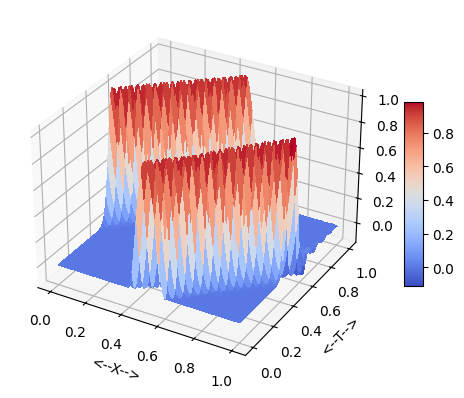


FD1D_ADVECTION_LAX_WENDROFF_TEST
  Normal end of execution.
Mon Sep  8 15:32:09 2025


In [1]:
#! /usr/bin/env python
#
def fd1d_advection_lax_wendroff (probtype, nx, nt, c ):

#*****************************************************************************80
#
## FD1D_ADVECTION_LAX_WENDROFF: advection equation using LAX-WENDROFF method.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    06 January 2015
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    Input, integer NX, the number of spatial nodes.
#    101 is a reasonable value.
#
#    Input, integer NT, the number of time steps.
#    1000 is a reasonable value.
#
#    Input, real C, the velocity.
#    1.0 is a reasonable value.
#
  import numpy as np
  from mpl_toolkits.mplot3d.axes3d import Axes3D
  import matplotlib.pyplot as plt
  from matplotlib import cm
  from mpl_toolkits.mplot3d.axes3d import get_test_data
#
#  Print the input.
#
  print ( '' )
  print ( '  probtype = %d' % (probtype) )
  print ( '  Number of nodes NX = %d' % ( nx ) )
  print ( '  Number of time steps NT = %d' % ( nt ) )
  print ( '  Constant velocity C = %g' % ( c ) )
#
#  Set some constants.
#
  dx = 1.0 / ( nx - 1 )
  x = np.linspace ( 0.0, 1.0, nx )
  tstop=1.0
  dt = tstop / nt
  c1 = 0.5 *   c * dt / dx
  c2 = 0.5 * ( c * dt / dx ) ** 2

  print ( '  CFL condition: dt = (%g) <= (%g) = dx / c' % ( dt, dx / c ) )
#
#  Set some arrays.
#
  u = np.zeros ( nx )
  unew = np.zeros ( nx )
  X = np.zeros ( [ nx, nt + 1 ] )
  Y = np.zeros ( [ nx, nt + 1 ] )
  Z = np.zeros ( [ nx, nt + 1 ] )
#
#  Compute the solution from times 0/NT ... NT/NT
#
  for j in range ( 0, nt + 1 ):

    t = tstop*float ( j ) / float ( nt )

    if ( j == 0 ):
      for i in range ( 0, nx ):
        if ( 0.4 <= x[i] and x[i] <= 0.6 ):
          unew[i] = ( 10.0 * x[i] - 4.0 ) ** 2 * ( 6.0 - 10.0 * x[i] ) ** 2
    else:
      if ( probtype == 0 ):
        unew[0] = u[0] - c1 * ( u[1] - u[nx-1] ) + c2 * ( u[1] - 2.0 * u[0] + u[nx-1] )
      else:
        unew[0]=g(t+dt)

      for i in range ( 1, nx - 1 ):
        unew[i] = u[i] - c1 * ( u[i+1] - u[i-1] ) + c2 * ( u[i+1] - 2.0 * u[i] + u[i-1] )

      if ( probtype == 0 ):
        unew[nx-1] = u[nx-1] - c1 * ( u[0] - u[nx-2] ) + c2 * ( u[0] - 2.0 * u[nx-1] + u[nx-2] )
      else:
        unew[nx-1]=u[nx-1]-2.0*c1*(u[nx-1]-u[nx-2])

    for i in range ( 0, nx ):
      u[i] = unew[i]
      X[i,j] = x[i]
      Y[i,j] = t
      Z[i,j] = u[i]
#
#  Make a plot.
#  These commands will fail on an older version of Python.
#
  fig = plt.figure ( )
  ax = fig.add_subplot ( projection = '3d' )
  surf = ax.plot_surface ( X, Y, Z, cmap = cm.coolwarm, \
   linewidth = 0, antialiased = False )
  ax.set_xlabel ( '<--X-->' )
  ax.set_ylabel ( '<--T-->' )
  ax.set_zlabel ( '<--U(X,T)-->' )
  fig.colorbar ( surf, shrink = 0.5, aspect = 10 )
  plt.savefig ( 'fd1d_advection_lax_wendroff.png' )
  plt.show ( )

  return

def fd1d_advection_lax_wendroff_test ( ):

#*****************************************************************************80
#
## FD1D_ADVECTION_LAX_WENDROFF_TEST tests FD1D_AVECTION_LAX_WENDROFF.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    06 January 2015
#
#  Author:
#
#    John Burkardt
#
  import platform

  print ( '' )
  print ( 'FD1D_ADVECTION_LAX_WENDROFF:' )
  print ( '  Python version: %s' % ( platform.python_version ( ) ) )
  print ( '' )
  print ( '  FD1D_ADVECTION_LAX_WENDROFF solves the constant-velocity ' )
  print ( '  advection equation in 1D,' )
  print ( '    du/dt = - c du/dx' )
  print ( '  over the interval:' )
  print ( '    0.0 <= x <= 1.0' )
  print ( '  with periodic (or Dirichlet!) boundary conditions, and' )
  print ( '  with a given initial condition' )
  print ( '    u(0,x) = (10x-4)^2 (6-10x)^2 for 0.4 <= x <= 0.6' )
  print ( '           = 0 elsewhere.' )
  print ( '' )
  print ( '  We use the Lax-Wendroff method.' )

  nx = 101
  nt = 1000
  c = 1.0
  probtype = 0 # periodic bc
  #probtype = 1 # dirichlet bc


  fd1d_advection_lax_wendroff (probtype, nx, nt, c )
#
#  Terminate.
#
  print ( '' )
  print ( 'FD1D_ADVECTION_LAX_WENDROFF_TEST' )
  print ( '  Normal end of execution.' )
  return

def g(t):
  y=t+1
  return y

def timestamp ( ):

#*****************************************************************************80
#
## TIMESTAMP prints the date as a timestamp.
#
#  Licensing:
#
#    This code is distributed under the GNU LGPL license.
#
#  Modified:
#
#    06 April 2013
#
#  Author:
#
#    John Burkardt
#
#  Parameters:
#
#    None
#
  import time

  t = time.time ( )
  print ( time.ctime ( t ) )

  return None

if ( __name__ == '__main__' ):
  timestamp ( )
  fd1d_advection_lax_wendroff_test ( )
  timestamp ( )